# 📊 Simple Stock Return Model — Learning-Focused Quant Project

This project is designed to develop a strong, practical understanding of the end-to-end machine learning pipeline applied to financial time series data, with a primary focus on learning and intuition rather than achieving high predictive accuracy.

---

## 🎯 Objective

The goal of this project is to explore and implement a complete regression workflow on stock data, while critically evaluating the effectiveness of each step in a realistic financial setting.

The project covers:

- Feature engineering (momentum, volatility, volume change, lagged returns, rolling statistics, interaction terms, and nonlinear features)
- Data preprocessing (handling missing values, outlier removal using quantile filtering)
- Feature scaling (standardization using z-score normalization)
- Exploratory data analysis (EDA) and visualization
- Model training using linear regression implemented via gradient descent
- Model evaluation using R² and visual diagnostics

---

## 🧠 Feature Engineering Approach

To enhance model expressiveness beyond basic features, several transformations were introduced:

- **Lag features**: past returns (`Return_lag1`, `Return_lag5`)
- **Rolling statistics**:
  - Momentum (rolling mean of returns)
  - Volatility (rolling standard deviation)
- **Interaction terms**:
  - Momentum × Volatility
  - Momentum × Volume Change
- **Nonlinear transformations**:
  - Squared features (e.g., `Momentum²`, `Volatility²`)

These were designed to capture:
- temporal dependencies
- nonlinear relationships
- interaction effects between market variables

---

## 📈 Results & Model Comparison

Two models were compared:

|      Model    |                    Features Used                          |      R²    |
|---------------|-----------------------------------------------------------|------------|
| Baseline      | Momentum, Volatility, Volume Change                       | **0.0066** |
| Engineered    | Full feature set (lag, rolling, interaction, nonlinear)   | **0.0659** |

### 🔍 Key Observations

- The baseline model shows **near-zero explanatory power**, indicating that simple raw features alone are insufficient to capture return dynamics.
- The model without feature engineering tends to produce **near-constant predictions**, a sign of severe underfitting.
- Feature engineering improves R² by nearly **10×**, suggesting that additional structure (temporal and nonlinear) introduces meaningful signal.
- Despite improvement, the overall R² remains low, reflecting the **inherently noisy and weakly predictable nature of financial returns**.

---

## 📊 Visualization Insights

- Scatter plots of **Actual vs Predicted returns** show:
  - Baseline model → tightly clustered predictions near zero (low variance)
  - Engineered model → increased spread and responsiveness to input features
- The addition of a **perfect-fit reference line (y = x)** highlights that predictions remain far from ideal alignment
- Regression trend lines indicate only **weak linear relationships**, consistent with low signal environments

---

## ⚠️ Key Learnings

This project highlights several important realities of quantitative modeling:

- Financial markets exhibit **low signal-to-noise ratio**, making prediction inherently difficult
- Even with feature engineering, improvements are often **incremental rather than dramatic**
- Proper preprocessing (scaling, outlier handling) is critical for stable optimization
- Linear models can capture only limited structure unless enriched with engineered features
- Evaluation metrics like R² must be interpreted carefully in financial contexts


---

## 🧩 Summary

This project demonstrates the full pipeline from raw financial data to model evaluation, with a strong emphasis on understanding *why* models behave the way they do.

Rather than focusing on predictive performance alone, the project builds intuition around:
- feature design
- model limitations
- and the gap between theoretical machine learning and real-world financial data

It provides a solid stepping stone toward more advanced quantitative research and model development.

In [253]:
# Packages used
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import r2_score

### Functions:

In [254]:
# Gradient descent function 
def run_gradient_descent(x_train, y_train, w, b, iteration, alpha):
    x_train = np.array(x_train, dtype=float)
    y_train = np.array(y_train, dtype=float)
    w = np.array(w, dtype=float)
    
    m, n = x_train.shape
    J_history = []
    w_history = []
    b_history = []

    for _ in range (iteration):
        # 1. Prediction for all the rows
        y_pred = x_train @ w + b

        #2. Error for all rows
        err = y_pred - y_train
        
        # 3. Cost
        cost = np.sum(err**2) / (2 * m)
        J_history.append(cost)

        # Store parameter history
        J_history.append(cost)
        w_history.append(w)
        b_history.append(b)

        # 4, Gradients
        dj_dw = x_train.T @ err / m
        dj_db = np.sum(err)/m

        #5. Update
        w = w - alpha * dj_dw # substrating array 
        b = b - alpha * dj_db
    return w, b, J_history, w_history, b_history

# Removing outliers from the features (x-train)
def remove_outlier(df,columns):
    for col in columns:
        q_low = df[col].quantile(0.01)
        q_high = df[col].quantile(0.99)
        
        filtered = df[
        (df[col] >= q_low) &
        (df[col] <= q_high)   
        ]

    return filtered

### Main Code:

#### Data(Feature, Target) extraction, preparation and analysis

In [255]:
# Input the ticker
ticker = input("Key in the ticker:")
timeframe_cutoff = 5 #(days)

In [256]:
# Data extraction from yfinance for selected ticker  
df= yf.download(ticker, start="2025-01-01")
df.columns = df.columns.droplevel(1)
print(f"{ticker} Raw Data Check:")
print(df)

[*********************100%***********************]  1 of 1 completed

AAPL Raw Data Check:
Price            Close        High         Low        Open    Volume
Date                                                                
2025-01-02  242.525162  247.746638  240.506192  247.577549  55740700
2025-01-03  242.037811  242.853348  240.575797  242.037811  40244100
2025-01-06  243.668900  245.986242  241.878676  242.982646  45045600
2025-01-07  240.894073  244.215924  240.038745  241.659879  40856000
2025-01-08  241.381393  242.385916  238.745797  240.605632  37628900
...                ...         ...         ...         ...       ...
2026-03-17  254.229996  255.130005  252.179993  252.960007  32361600
2026-03-18  249.940002  254.940002  249.000000  252.630005  35757900
2026-03-19  248.960007  251.830002  247.300003  249.399994  34864100
2026-03-20  247.990005  249.199997  246.000000  247.979996  88268000
2026-03-23  251.809998  254.559998  250.279999  253.990005  25573018

[305 rows x 5 columns]


In [257]:
#Adding Feature Columns (Volume Change, Momentum and Volatility)

df["Return"] = df["Close"].pct_change()
df["Volume Change"] = df["Volume"].pct_change()

# Momentum past 5 days 
df["Momentum"] = df["Volume"].pct_change(timeframe_cutoff)

# Volatility (rolling std)
df["Volatility"] = df["Return"].pct_change(timeframe_cutoff)

#Target: next-day return
df["Next Return"] = df["Return"].shift(-1)

# Cleaning df
df= df.dropna()
df.columns.name = None
df.reset_index().head()


,Date,Close,High,Low,Open,Volume,Return,Volume Change,Momentum,Volatility,Next Return
0,2025-01-13,233.126495,233.395033,228.471929,232.261227,49630700,-0.010344,-0.195755,0.233242,4.147612,-0.004778
1,2025-01-14,232.012589,234.837155,231.206992,233.474603,39435300,-0.004778,-0.205425,-0.124547,-1.709027,0.019676
2,2025-01-15,236.577652,237.661742,233.156339,233.365205,39832000,0.019676,0.010060,-0.025064,-2.727824,-0.040400
3,2025-01-16,227.019852,236.716880,226.791106,236.060477,71759100,-0.040400,0.801544,0.907021,-20.970832,0.007535
4,2025-01-17,228.730515,231.027962,227.238664,230.858887,68488300,0.007535,-0.045580,0.109825,-1.312618,-0.031916


In [258]:
# Create feature(y) dataframe and normalized Features
features = ["Momentum", "Volatility", "Volume Change"]
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])
features_df = df[features]
features_df.columns.name = None
features_df.reset_index().head()


,Date,Momentum,Volatility,Volume Change
0,2025-01-13,0.205325,0.310721,-0.642676
1,2025-01-14,-0.409035,-0.078564,-0.666947
2,2025-01-15,-0.238212,-0.146282,-0.126131
3,2025-01-16,1.362275,-1.358877,1.860310
4,2025-01-17,-0.006594,-0.052215,-0.265774


In [259]:
# Create target(x) dataframe
target = ["Return", "Next Return"]
target_df = df[target]
target_df.reset_index().head()

,Date,Return,Next Return
0,2025-01-13,-0.010344,-0.004778
1,2025-01-14,-0.004778,0.019676
2,2025-01-15,0.019676,-0.040400
3,2025-01-16,-0.040400,0.007535
4,2025-01-17,0.007535,-0.031916


In [260]:
# Merging Feature and Target
stocks_data = pd.merge(features_df,target_df, on="Date")
stocks_data.reset_index(inplace=True)
stocks_data.head()


,Date,Momentum,Volatility,Volume Change,Return,Next Return
0,2025-01-13,0.205325,0.310721,-0.642676,-0.010344,-0.004778
1,2025-01-14,-0.409035,-0.078564,-0.666947,-0.004778,0.019676
2,2025-01-15,-0.238212,-0.146282,-0.126131,0.019676,-0.040400
3,2025-01-16,1.362275,-1.358877,1.860310,-0.040400,0.007535
4,2025-01-17,-0.006594,-0.052215,-0.265774,0.007535,-0.031916


In [261]:
# Removing outliers
cleaned_stocks_data = remove_outlier(stocks_data, features)
print(f"Cleaned {ticker} dataframe:\n",cleaned_stocks_data.head())


Cleaned AAPL dataframe:
         Date  Momentum  Volatility  Volume Change    Return  Next Return
0 2025-01-13  0.205325    0.310721      -0.642676 -0.010344    -0.004778
1 2025-01-14 -0.409035   -0.078564      -0.666947 -0.004778     0.019676
2 2025-01-15 -0.238212   -0.146282      -0.126131  0.019676    -0.040400
3 2025-01-16  1.362275   -1.358877       1.860310 -0.040400     0.007535
4 2025-01-17 -0.006594   -0.052215      -0.265774  0.007535    -0.031916


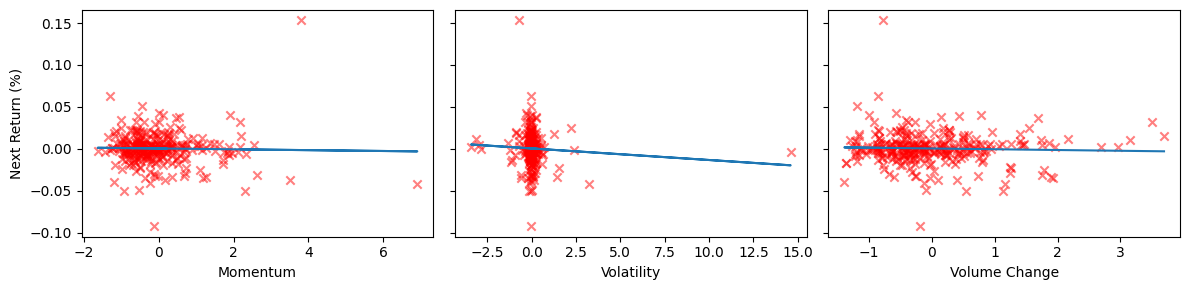

In [262]:
#Features correlation plotting for analysis
fig, ax = plt.subplots(1, len(features), figsize=(12, 3), sharey=True)

for i, feature in enumerate(features):
    x = cleaned_stocks_data[feature]
    y = cleaned_stocks_data["Next Return"]

    # scatter
    ax[i].scatter(x, y, marker="x",c="r",alpha=0.5)

    # regression line
    m, b = np.polyfit(x, y, 1)
    ax[i].plot(x, m*x + b)

    ax[i].set_xlabel(feature)

ax[0].set_ylabel("Next Return (%)")
plt.tight_layout()
plt.show()

#### Gradient Descent without feature engineering

In [263]:
# Input for Gradient descent w/o feature engineering
w_init = np.zeros(len(features))
b_init = 0.0
iteration = 10000
alpha = 0.001
w_final, b_final, J_history, w_history, b_history = run_gradient_descent(cleaned_stocks_data[features],cleaned_stocks_data["Next Return"], w_init, b_init, iteration, alpha)

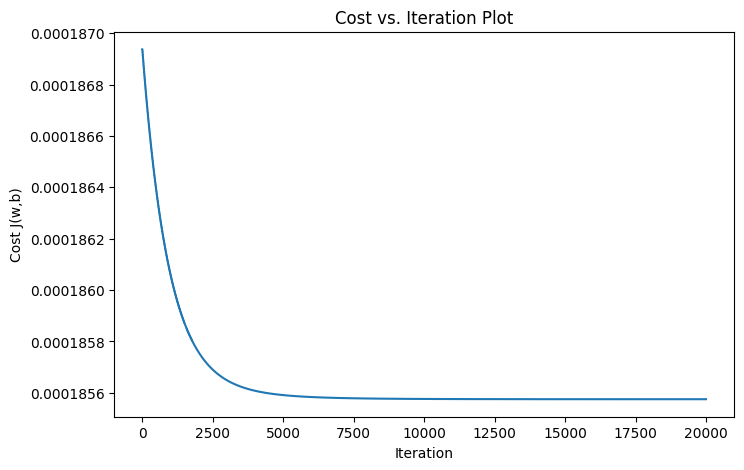

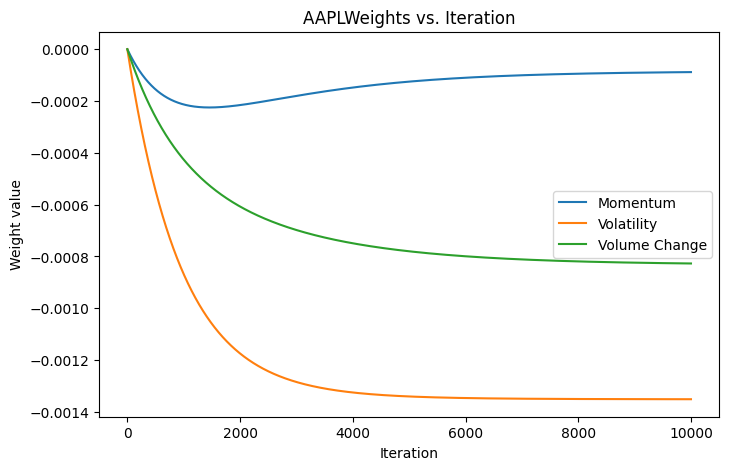

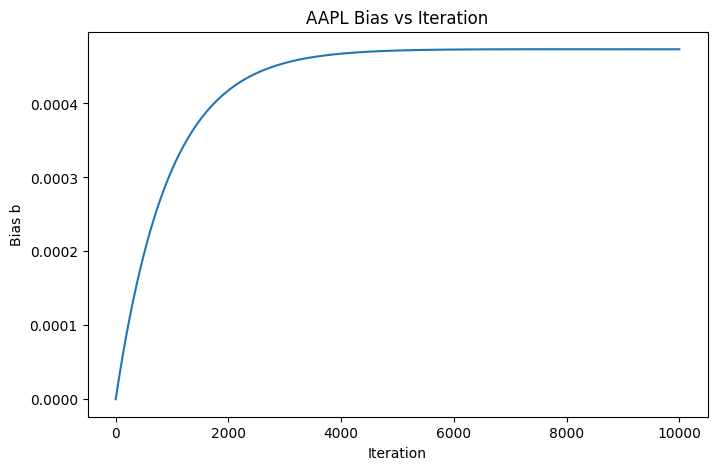

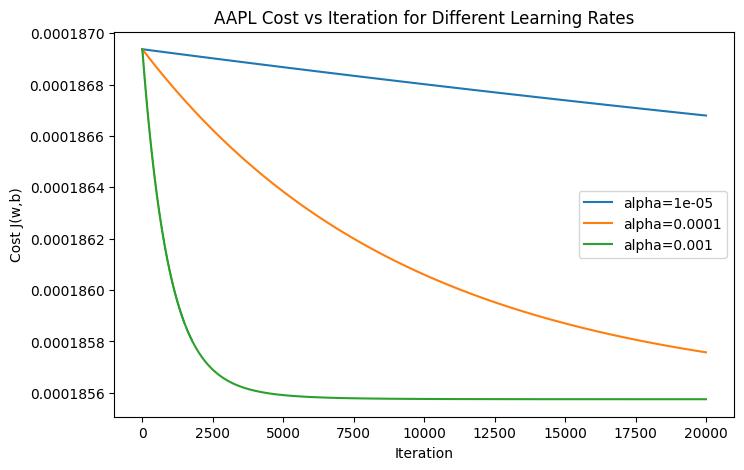

In [264]:
# Cost vs. iteration chart
plt.figure(figsize=(8,5))
plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs. Iteration Plot")
plt.show()

# Plot weight history for each iteration
w_history_arr = np.array(w_history)

plt.figure(figsize=(8,5))
for i in range (w_history_arr.shape[1]):
    plt.plot(w_history_arr[:,i], label=f"{features[i]}")
plt.xlabel("Iteration")
plt.ylabel("Weight value")
plt.title(f"{ticker}Weights vs. Iteration")
plt.legend()
plt.show()

# Plot bias (b) for each iteration
plt.figure(figsize=(8,5))
plt.plot(b_history)
plt.xlabel("Iteration")
plt.ylabel("Bias b")
plt.title(f"{ticker} Bias vs Iteration")
plt.show()

# Comparing cost vs. iteration for different learning rate (alpha)
alphas = [0.00001, 0.0001, 0.001]
plt.figure(figsize=(8,5))

for alpha in alphas:
    w_final, b_final, J_history, _, _ = run_gradient_descent(
        cleaned_stocks_data[features],
        cleaned_stocks_data["Next Return"],
        w_init,
        b_init,
        iteration,
        alpha
    )
    plt.plot(J_history, label=f"alpha={alpha}")

plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title(f"{ticker} Cost vs Iteration for Different Learning Rates")
plt.legend()
plt.show()

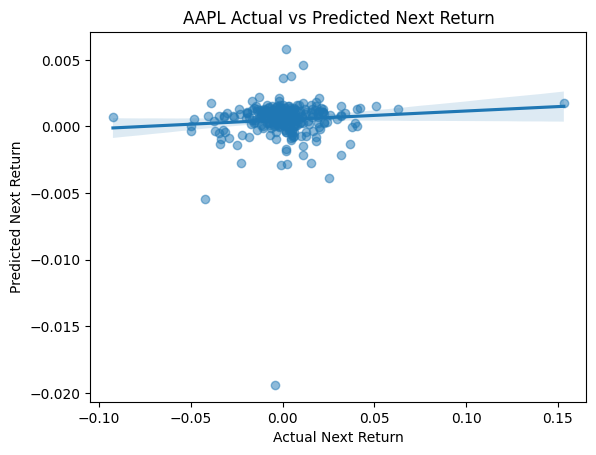

AAPL Next Return Model 
Without Feature Engineering Summary:

R²: 0.0066101518205509135
Momentum Weight: -0.000088
Volatility Weight: -0.001352
Volume Change Weight: -0.000827
Bias: 0.000473


In [265]:
# ==========================================
# Model Evaluation: Actual vs Predicted Plot
# ==========================================

# Convert feature matrix and target into numpy arrays
# X_np: Feature matrix used for prediction (same features as training)
# y_np: Ground truth target (Next Return)X_np = np.array(cleaned_stocks_data[features], dtype=float)
X_np = np.array(cleaned_stocks_data[features], dtype=float)
y_np = np.array(cleaned_stocks_data["Next Return"], dtype=float)

# Generate model predictions using trained parameters
# y_pred = Xw + b
y_pred_final = X_np @ w_final + b_final

# ==========================================
# Visualization: Prediction vs Reality
# ==========================================

# Plot predicted vs actual values
# x-axis: Actual Next Return (ground truth)
# y-axis: Predicted Next Return (model output)
sns.regplot(
    y = y_pred_final,
    x = y_np,
    scatter_kws={"alpha": 0.5}
)
plt.ylabel("Predicted Next Return")
plt.xlabel("Actual Next Return")
plt.title(f"{ticker} Actual vs Predicted Next Return")
plt.show()

# ==========================================
# Performance Metric: R² Score
# ==========================================
print(f"{ticker} Next Return Model \nWithout Feature Engineering Summary:\n")
# R² measures how well predictions explain variance in actual values
# R² = 1 → perfect fit
# R² = 0 → same as predicting mean
# R² < 0 → worse than naive model
r2 = r2_score(y_np, y_pred_final) # for r2score (Actual_value, Predictive value)
print("R²:", r2)

# ==========================================
# Model Interpretation: Feature Weights
# ==========================================

# Display learned coefficients for each feature
# Helps interpret feature importance in linear model
for feature, weight in zip(features, w_final):
    print(f"{feature} Weight: {weight:.6f}")


# Bias term (intercept)
print(f"Bias: {b_final:.6f}")

In [266]:
# =========================
# Feature Engineering
# =========================

# Dataframe preparation
df_fe = cleaned_stocks_data.copy()
df_fe["Next Return"] = df_fe["Return"].shift(-1)

# 1. Lag features
df_fe["Return_lag1"] = df_fe["Return"].shift(1)
df_fe["Return_lag5"] = df_fe["Return"].shift(5)

# 2. Rolling statistics
df_fe["Momentum_5"] = df_fe["Return"].rolling(5).mean()
df_fe["Momentum_10"] = df_fe["Return"].rolling(10).mean()

df_fe["Volatility_5"] = df_fe["Return"].rolling(5).std()
df_fe["Volatility_10"] = df_fe["Return"].rolling(10).std()

# 3. Interaction features
df_fe["Mom_x_Vol"] = df_fe["Momentum"] * df_fe["Volatility"]
df_fe["Mom_x_VolChange"] = df_fe["Momentum"] * df_fe["Volume Change"]

# 4. Non-linear features
df_fe["Momentum_sq"] = df_fe["Momentum"] ** 2
df_fe["Volatility_sq"] = df_fe["Volatility"] ** 2

# Drop NaN
df_fe = df_fe.dropna()

new_features = [
    "Momentum", "Volatility", "Volume Change",
    "Return_lag1", "Return_lag5",
    "Momentum_5", "Momentum_10",
    "Volatility_5", "Volatility_10",
    "Mom_x_Vol", "Mom_x_VolChange",
    "Momentum_sq", "Volatility_sq"
]
cleaned_df_fe = remove_outlier(df_fe,new_features)
target = "Next Return"

# X_scaled and y
X_scaled = cleaned_df_fe[new_features].values
y = cleaned_df_fe[target].values

#Property Check
print("X shape:", X_scaled.shape)
print("y shape:", y.shape)

print("NaN in X:", np.isnan(X_scaled).sum())
print("Inf in X:", np.isinf(X_scaled).sum())

print("NaN in y:", np.isnan(y).sum())
print("Inf in y:", np.isinf(y).sum())

print("Max abs X:", np.max(np.abs(X_scaled)))
print("Max abs y:", np.max(np.abs(y)))
cleaned_df_fe = cleaned_df_fe.reset_index(drop=True)
cleaned_df_fe.columns.name = None
cleaned_df_fe.reset_index().head()


X shape: (276, 13)
y shape: (276,)
NaN in X: 0
Inf in X: 0
NaN in y: 0
Inf in y: 0
Max abs X: 14.341842613579539
Max abs y: 0.1532884850891707


,index,Date,Momentum,Volatility,Volume Change,Return,Next Return,Return_lag1,Return_lag5,Momentum_5,Momentum_10,Volatility_5,Volatility_10,Mom_x_Vol,Mom_x_VolChange,Momentum_sq,Volatility_sq
0,0,2025-01-27,0.466089,0.248899,1.691582,0.031780,0.036544,-0.003935,0.007535,0.000103,-0.002780,0.022766,0.021607,0.116009,0.788427,0.217239,0.061951
1,1,2025-01-28,-0.586723,-0.107543,-0.658176,0.036544,0.004617,0.031780,-0.031916,0.013795,0.001909,0.018964,0.024656,0.063098,0.386167,0.344244,0.011566
2,2,2025-01-29,-0.694306,0.025979,-1.153244,0.004617,-0.007395,0.036544,0.005345,0.013649,0.002849,0.019048,0.024551,-0.018037,0.800704,0.482061,0.000675
3,3,2025-01-30,-0.325637,0.615824,0.409889,-0.007395,-0.006692,0.004617,-0.000759,0.012322,0.000142,0.020480,0.023976,-0.200535,-0.133475,0.106039,0.379239
4,4,2025-01-31,1.257103,0.081615,1.891376,-0.006692,-0.033856,-0.007395,-0.003935,0.011771,0.003512,0.021056,0.019615,0.102599,2.377653,1.580307,0.006661


In [267]:
# Input for feature engineering
w_init_engineering = np.zeros(len(new_features))
b_init_engineering = 0.002
alpha_engineering = 0.001
iteration_engineering = 10000

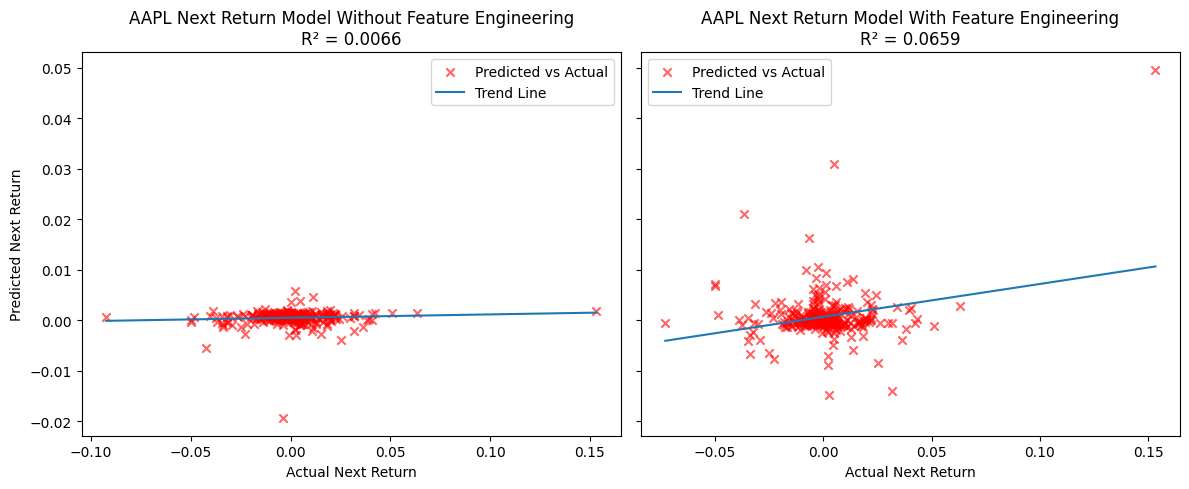

AAPL Next Return Model 
With Feature Engineering Summary:

R²: 0.06593755228896692
Momentum Weight: -0.001985
Volatility Weight: -0.000824
Volume Change Weight: 0.000135
Return_lag1 Weight: 0.000078
Return_lag5 Weight: 0.000004
Momentum_5 Weight: -0.000083
Momentum_10 Weight: -0.000112
Volatility_5 Weight: 0.000069
Volatility_10 Weight: 0.000092
Mom_x_Vol Weight: -0.002720
Mom_x_VolChange Weight: -0.003289
Momentum_sq Weight: 0.002803
Volatility_sq Weight: 0.000025
Bias: -0.000656


In [268]:
# ==========================================
# Model Comparison: Baseline vs Engineered Features
# ==========================================

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)


# -------------------------
# Baseline Model
# -------------------------
# Scatter: Actual vs Predicted
x_base = np.array(cleaned_stocks_data["Next Return"], dtype=float)
y_base = np.array(y_pred_final, dtype=float)

ax[0].scatter(x_base, y_base, marker="x", c="r", alpha=0.6, label="Predicted vs Actual")

# regression line
m_base, b_base = np.polyfit(x_base, y_base, 1)
x_line_base = np.linspace(x_base.min(), x_base.max(), 200)
ax[0].plot(x_line_base, m_base * x_line_base + b_base, label="Trend Line")

ax[0].set_title(f"{ticker} Next Return Model Without Feature Engineering\nR² = {r2:.4f}")
ax[0].set_xlabel("Actual Next Return")
ax[0].set_ylabel("Predicted Next Return")
ax[0].legend()

# -------------------------
# Engineered Model
# -------------------------
x_eng = np.array(cleaned_df_fe["Next Return"], dtype=float)
y_eng = np.array(y_pred_final_engineering, dtype=float)

ax[1].scatter(x_eng, y_eng, marker="x", c="r", alpha=0.6, label="Predicted vs Actual")

# regression line
m_eng, b_eng = np.polyfit(x_eng, y_eng, 1)
x_line_eng = np.linspace(x_eng.min(), x_eng.max(), 200)
ax[1].plot(x_line_eng, m_eng * x_line_eng + b_eng, label="Trend Line")

ax[1].set_title(f"{ticker} Next Return Model With Feature Engineering\nR² = {r2_engineering:.4f}")
ax[1].set_xlabel("Actual Next Return")
ax[1].legend()

plt.tight_layout()
plt.show()
# Gradient descent for feature engineering
w_final_engineering, b_final_engineering, J_history, w_history, b_history = run_gradient_descent(
    cleaned_df_fe[new_features],cleaned_df_fe["Next Return"], w_init_engineering, b_init_engineering, iteration_engineering, alpha_engineering
)
X_np_engineering = np.array(cleaned_df_fe[new_features], dtype=float)
y_np_engineering = np.array(cleaned_df_fe["Next Return"], dtype=float)
y_pred_final_engineering = X_np_engineering @ w_final_engineering  + b_final_engineering

print(f"{ticker} Next Return Model \nWith Feature Engineering Summary:\n")
# R² measures how well predictions explain variance in actual values
# R² = 1 → perfect fit
# R² = 0 → same as predicting mean
# R² < 0 → worse than naive model
r2_engineering = r2_score(y_np_engineering , y_pred_final_engineering, )
print("R²:", r2_engineering)

# ==========================================
# Model Interpretation: Feature Weights
# ==========================================

# Display learned coefficients for each feature
# Helps interpret feature importance in linear model
for new_feature, w_final_engineering in zip(new_features, w_final_engineering):
    print(f"{new_feature} Weight: {w_final_engineering:.6f}")

# Bias term (intercept)
print(f"Bias: {b_final_engineering:.6f}")